Starting RailPulse-AI Delay Classification...

Dataset loaded!
Shape: (5000, 15)

Target distribution:
is_delayed
1    3225
0    1775
Name: count, dtype: int64

Features prepared!
X shape: (5000, 8)
Y shape: (5000,)

Train: (4000, 8)
Test : (1000, 8)

MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.849     0.8665  0.9054    0.8855
      Random Forest     0.840     0.8530  0.9085    0.8799

Best Model: Logistic Regression

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.81      0.75      0.78       355
     Delayed       0.87      0.91      0.89       645

    accuracy                           0.85      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.85      0.85      0.85      1000


CONFUSION MATRIX
[[265  90]
 [ 61 584]]


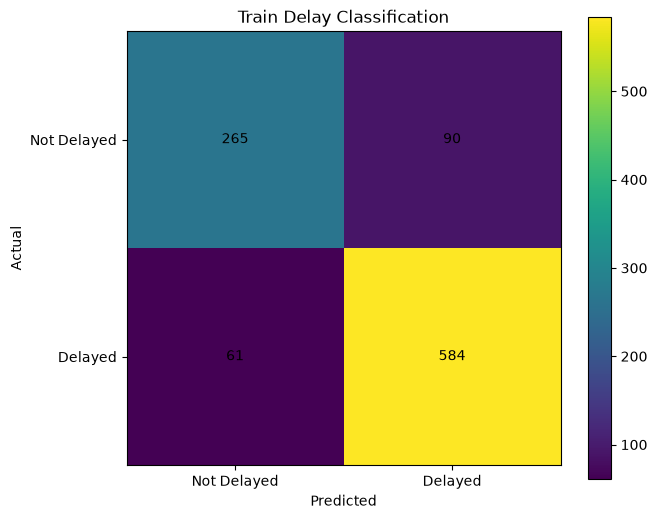


SAMPLE PREDICTIONS
 Actual  Predicted Actual_Label Predicted_Label
      1          1      Delayed         Delayed
      0          0  Not Delayed     Not Delayed
      1          1      Delayed         Delayed
      0          0  Not Delayed     Not Delayed
      1          1      Delayed         Delayed
      0          0  Not Delayed     Not Delayed
      0          0  Not Delayed     Not Delayed
      1          1      Delayed         Delayed
      1          1      Delayed         Delayed
      1          1      Delayed         Delayed
      1          1      Delayed         Delayed
      0          0  Not Delayed     Not Delayed
      1          1      Delayed         Delayed
      1          1      Delayed         Delayed
      0          0  Not Delayed     Not Delayed

Model saved successfully!
Path: ../models/classification/delay_classifier.pkl
Predictions saved: ../data/processed/delay_classification_predictions.csv


🎉 05 DELAY CLASSIFICATION COMPLETED!


In [1]:
# ============================================================
# RAILPULSE-AI
# 05 - TRAIN DELAY CLASSIFICATION
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Starting RailPulse-AI Delay Classification...")


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../data/processed/delay_processed.csv")

print("\nDataset loaded!")
print("Shape:", df.shape)


# ============================================================
# 2. CREATE FEATURES SAFELY
# ============================================================

# Departure hour
if "departure_hour" not in df.columns:

    if "scheduled_departure" in df.columns:

        df["departure_hour"] = pd.to_datetime(
            df["scheduled_departure"],
            format="%H:%M",
            errors="coerce"
        ).dt.hour

    else:
        raise ValueError(
            "departure_hour / scheduled_departure not found"
        )


# Peak hour
if "is_peak_hour" not in df.columns:

    df["is_peak_hour"] = (
        df["departure_hour"].between(7, 10)
        |
        df["departure_hour"].between(17, 21)
    ).astype(int)


# Weather encoding
if "weather_encoded" not in df.columns:

    weather_mapping = {
        "Clear": 0,
        "Cloudy": 1,
        "Rain": 2,
        "Heavy Rain": 3,
        "Fog": 4
    }

    df["weather_encoded"] = (
        df["weather"]
        .map(weather_mapping)
        .fillna(0)
    )


# ============================================================
# 3. CREATE TARGET
# ============================================================

# 15 minutes or more = Delayed
df["is_delayed"] = (
    df["delay_minutes"] >= 15
).astype(int)

print("\nTarget distribution:")
print(df["is_delayed"].value_counts())


# ============================================================
# 4. SELECT FEATURES
# ============================================================

features = [
    "distance_km",
    "temperature",
    "rainfall",
    "station_delay",
    "previous_delay",
    "departure_hour",
    "is_peak_hour",
    "weather_encoded"
]

target = "is_delayed"


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

missing = [
    col for col in features + [target]
    if col not in df.columns
]

if missing:

    raise ValueError(
        f"Missing columns: {missing}"
    )


# ============================================================
# 6. CREATE X AND Y
# ============================================================

X = df[features].copy()
y = df[target].copy()


# ============================================================
# 7. HANDLE MISSING VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median(numeric_only=True)
)

print("\nFeatures prepared!")
print("X shape:", X.shape)
print("Y shape:", y.shape)


# ============================================================
# 8. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)


# ============================================================
# 9. LOGISTIC REGRESSION
# ============================================================

logistic_model = LogisticRegression(
    max_iter=2000
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)


# ============================================================
# 10. LOGISTIC METRICS
# ============================================================

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    zero_division=0
)


# ============================================================
# 11. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(

    n_estimators=200,

    max_depth=15,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)


# ============================================================
# 12. RANDOM FOREST METRICS
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    zero_division=0
)


# ============================================================
# 13. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

print("\n======================================")
print("MODEL COMPARISON")
print("======================================")

print(
    comparison.round(4).to_string(index=False)
)


# ============================================================
# 14. SELECT BEST MODEL
# ============================================================

if rf_f1 >= logistic_f1:

    best_model = rf_model
    best_model_name = "Random Forest"
    best_pred = rf_pred

else:

    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_pred = logistic_pred


print("\nBest Model:", best_model_name)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\n======================================")
print("CLASSIFICATION REPORT")
print("======================================")

print(
    classification_report(
        y_test,
        best_pred,
        target_names=[
            "Not Delayed",
            "Delayed"
        ],
        zero_division=0
    )
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

print("\n======================================")
print("CONFUSION MATRIX")
print("======================================")

print(cm)


# ============================================================
# 17. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title(
    "Train Delay Classification"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Not Delayed", "Delayed"]
)

plt.yticks(
    [0, 1],
    ["Not Delayed", "Delayed"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()


# ============================================================
# 18. FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest":

    importance = pd.DataFrame({

        "Feature": features,

        "Importance":
            best_model.feature_importances_

    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print("\n======================================")
    print("FEATURE IMPORTANCE")
    print("======================================")

    print(
        importance.round(4).to_string(index=False)
    )

    plt.figure(figsize=(9, 6))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.title(
        "Delay Classification Feature Importance"
    )

    plt.gca().invert_yaxis()

    plt.show()


# ============================================================
# 19. SAMPLE PREDICTIONS
# ============================================================

results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": best_pred

})

results["Actual_Label"] = results[
    "Actual"
].map({
    0: "Not Delayed",
    1: "Delayed"
})

results["Predicted_Label"] = results[
    "Predicted"
].map({
    0: "Not Delayed",
    1: "Delayed"
})


print("\n======================================")
print("SAMPLE PREDICTIONS")
print("======================================")

print(
    results.head(15).to_string(index=False)
)


# ============================================================
# 20. SAVE MODEL
# ============================================================

model_folder = "../models/classification"

os.makedirs(
    model_folder,
    exist_ok=True
)

model_path = (
    model_folder +
    "/delay_classifier.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("\nModel saved successfully!")
print(
    "Path:",
    model_path
)


# ============================================================
# 21. SAVE PREDICTIONS
# ============================================================

prediction_path = (
    "../data/processed/"
    "delay_classification_predictions.csv"
)

results.to_csv(
    prediction_path,
    index=False
)

print(
    "Predictions saved:",
    prediction_path
)


# ============================================================
# 22. FINAL
# ============================================================

print("\n")
print("======================================")
print("🎉 05 DELAY CLASSIFICATION COMPLETED!")
print("======================================")